In [14]:
import pandas as pd
from datasets import Dataset

df = pd.read_csv("translation/csvs/big_translation_dataset.csv")

In [15]:
from datasets import load_dataset, load_from_disk, Value
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, RobertaTokenizerFast, RobertaForSequenceClassification, DataCollatorWithPadding
from transformers import RobertaTokenizer
from datasets import ClassLabel
import torch
import numpy as np
import evaluate
import requests
import pandas as pd



TOKENIZED_DATA_FILE = "data/sp-en/sp-machine-translation-10k_tokenized.parquet"
OUTPUT_DIR = "./data/sp-en/sp-machine-translation-10k-out"
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
ds = pd.read_csv("translation/csvs/big_translation_dataset.csv")
from datasets import Dataset
ds = Dataset.from_pandas(ds)



    
    

{'text': 'Resumption of the session', 'label': 0}


In [16]:

    
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=512)

tokenized_ds = (ds.map(tokenize_batch, batched=True).rename_column("label", "labels"))
tokenized_ds.to_parquet(TOKENIZED_DATA_FILE)

tokenized_ds = tokenized_ds.cast_column(
    "labels", 
    ClassLabel(num_classes=2, names=["0", "1"])

)


tokenized_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print(tokenized_ds.column_names)

print(tokenized_ds[0])

split = tokenized_ds.train_test_split(
    test_size=0.1, 
    seed=1865, 
    stratify_by_column="labels"
)

train_ds = split["train"]
test_ds = split["test"]

# check distribution
print("Train set distribution:", torch.bincount(torch.tensor(train_ds["labels"])))
print("Test set distribution:", torch.bincount(torch.tensor(test_ds["labels"])))

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_ds_full = train_ds


Casting the dataset: 100%|██████████| 24000/24000 [00:00<00:00, 4829829.00 examples/s]


['text', 'labels', 'input_ids', 'attention_mask']
{'labels': tensor(0), 'input_ids': tensor([    0, 20028, 21236,     9,     5,  1852,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1])}
Train set distribution: tensor([10800, 10800])
Test set distribution: tensor([1200, 1200])


In [8]:
# Decode tokenized input back to text to verify content
print(tokenizer.decode(train_ds[0]["input_ids"]))
print(tokenizer.decode(train_ds[1]["input_ids"]))
print("Label 0 example label:", train_ds[0]["labels"])
print("Label 1 example label:", train_ds[1]["labels"])

<s>I honestly believe that an evaluation of this type would not be in accordance with the reality of that situation.</s>
<s>I sincerely hope that, particularly during the French presidency later this year, the Commission and the Council will look carefully at all these options, and I heartily commend this resolution to Parliament.</s>
Label 0 example label: tensor(0)
Label 1 example label: tensor(0)


In [17]:


training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    bf16=False,
    dataloader_num_workers=8,
    dataloader_pin_memory=False,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=3e-5,
    weight_decay=0.0,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="tensorboard",
)
accuracy_metric = evaluate.load("accuracy")
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    problem_type="single_label_classification", 
)

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     return accuracy_metric.compute(predictions=predictions, references=labels)
def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 7160.55it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy
100,0.699000,0.685874,0.525417
200,0.681115,0.666595,0.581250
300,0.663412,0.656613,0.590833
400,0.669995,0.647057,0.612500
500,0.655525,0.654953,0.585000
600,0.630765,0.630991,0.632500
700,0.626408,0.630811,0.618333
800,0.616407,0.626837,0.647083
900,0.620979,0.649750,0.587917
1000,0.624599,0.604153,0.652500


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=4050, training_loss=0.5432439187132282, metrics={'train_runtime': 2500.2162, 'train_samples_per_second': 25.918, 'train_steps_per_second': 1.62, 'total_flos': 1669102535219520.0, 'train_loss': 0.5432439187132282, 'epoch': 3.0})

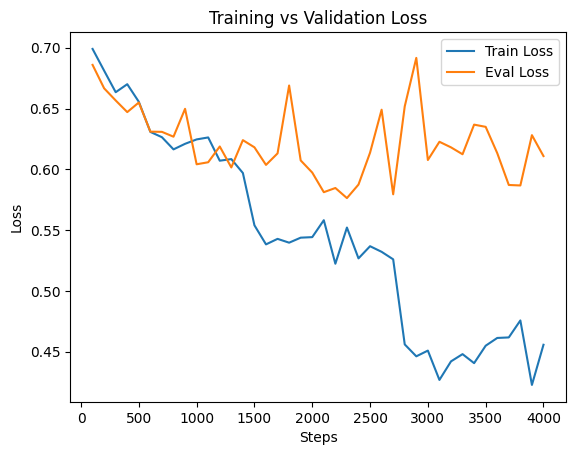

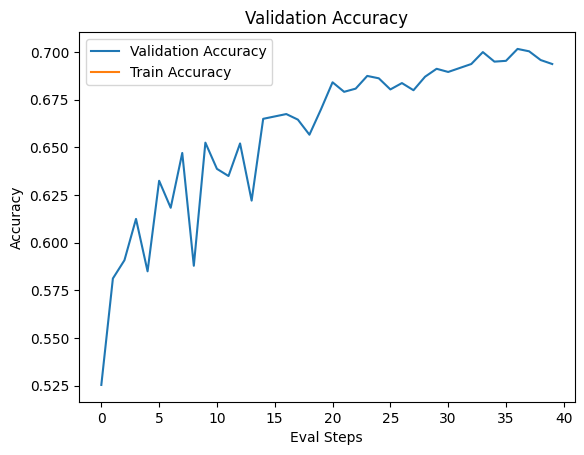

In [23]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
train_loss = []
eval_loss = []
train_accuracy = []
eval_accuracy = []
steps = []

for log in logs:
    if "loss" in log and "eval_loss" not in log:
        train_loss.append(log["loss"])
        train_accuracy.append(log.get("train_accuracy", None))
        steps.append(log["step"])
        

    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        eval_accuracy.append(log.get("eval_accuracy", None))
        
plt.plot(steps[:len(train_loss)], train_loss, label="Train Loss")
plt.plot(steps[:len(eval_loss)], eval_loss, label="Eval Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


plt.plot(eval_accuracy, label="Validation Accuracy")
plt.plot(train_accuracy, label="Train Accuracy")

plt.xlabel("Eval Steps")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

In [ ]:
indices = np.random.choice(len(test_ds), 30, replace=False)

small_ds = test_ds.select(indices)

pred_output = trainer.predict(small_ds)

preds = pred_output.predictions.squeeze()
labels = pred_output.label_ids

for i, idx in enumerate(indices):
    text = tokenizer.decode(test_ds[idx]["input_ids"], skip_special_tokens=True)
    print(f"Text: {text}")
    
    predicted_class = np.argmax(preds[i])
    actual_class = labels[i]
    
    print(f"Prediction: {predicted_class} | Label: {actual_class}")
    print("=" * 50)
    
    
eval_loss = None
train_loss = None
eval_rmse = None
for log in trainer.state.log_history:
    train_loss = log.get("train_loss") or train_loss
    eval_loss = log.get("eval_loss") or eval_loss
    eval_rmse = log.get("eval_rmse") or eval_rmse
    
    
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# predictions on test dataset
print("Running predictions on the full test dataset...")
full_pred_output = trainer.predict(test_ds)

# extract predictions and true labels
logits = full_pred_output.predictions
predicted_classes = np.argmax(logits, axis=-1)
true_classes = full_pred_output.label_ids

# classification metrics
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(true_classes, predicted_classes, target_names=["Human (0)", "Machine (1)"]))

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(true_classes, predicted_classes)
print(f"True Negatives (Human correctly identified): {cm[0][0]}")
print(f"False Positives (Human incorrectly flagged as Machine): {cm[0][1]}")
print(f"False Negatives (Machine missed as Human): {cm[1][0]}")
print(f"True Positives (Machine correctly identified): {cm[1][1]}")

# error analysis
print("\n" + "="*50)
print("ERROR ANALYSIS: SAMPLES OF MISCLASSIFIED TEXT")
print("="*50)

# filter for rows where the model made a mistake
df = pd.DataFrame({
    "text": [tokenizer.decode(ids, skip_special_tokens=True) for ids in test_ds["input_ids"]],
    "true_label": true_classes,
    "prediction": predicted_classes
})

errors_df = df[df["true_label"] != df["prediction"]]

# find false positives (human text predicted as machine)
false_positives = errors_df[(errors_df["true_label"] == 0) & (errors_df["prediction"] == 1)]
print(f"\nTotal False Positives: {len(false_positives)}")
if not false_positives.empty:
    print("Sample False Positive (Human text the model thought was Machine):")
    # Grab one random example
    print(f'"{false_positives.sample(1)["text"].values[0]}"')

# find false negatives (machine text predicted as human)
false_negatives = errors_df[(errors_df["true_label"] == 1) & (errors_df["prediction"] == 0)]
print(f"\nTotal False Negatives: {len(false_negatives)}")
if not false_negatives.empty:
    print("Sample False Negative (Machine text the model thought was Human):")
    print(f'"{false_negatives.sample(1)["text"].values[0]}"')

Text: The Alliance is present today on the ground with the same objective.
Prediction: 1 | Label: 1
Text: It is the manufacturer who has to provide the infrastructure and provide a reasonable part of the cost of disposal.
Prediction: 0 | Label: 0
Text: We will either be able to restore water quality to suit the planet' s ecosystem or we will experience a whole range of adverse events which will threaten the development of certain regions, the living conditions of the inhabitants of other regions and even, more fundamentally, the global balance.
Prediction: 0 | Label: 0
Text: Mr President, the Committee on Constitutional Affairs has proposed an essentially positive text, which I shall vote for, even if I personally had proposed a lot of amendments to broaden it.
Prediction: 1 | Label: 0
Text: That is why it is very important that it be the subject of international coordination.
Prediction: 0 | Label: 1
Text: I say therefore that we need a timetable which stipulates what must be implemen


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Human (0)       0.76      0.58      0.66      1200
 Machine (1)       0.66      0.82      0.73      1200

    accuracy                           0.70      2400
   macro avg       0.71      0.70      0.70      2400
weighted avg       0.71      0.70      0.70      2400


CONFUSION MATRIX
True Negatives (Human correctly identified): 702
False Positives (Human incorrectly flagged as Machine): 498
False Negatives (Machine missed as Human): 217
True Positives (Machine correctly identified): 983

ERROR ANALYSIS: SAMPLES OF MISCLASSIFIED TEXT

Total False Positives: 498
Sample False Positive (Human text the model thought was Machine):
"Mr President, Commissioner Patten has our understanding."

Total False Negatives: 217
Sample False Negative (Machine text the model thought was Human):
"Anyone who is British or English or cricket fan knows what a scorer is."


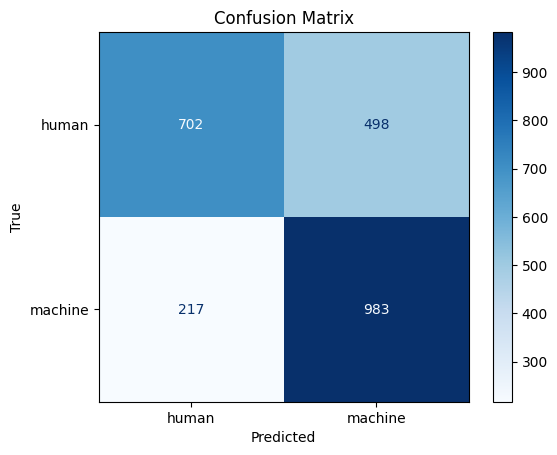

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["human", "machine"]  # adjust if needed

cm = confusion_matrix(df["true_label"], df["prediction"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()